<a href="https://colab.research.google.com/github/akt-developer/Student-Performance-Prediction-Project/blob/main/Copy_of_Sample_EDA_Submission_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -Student Performance Prediction Dashboard



##### **Project Type**      - EDA/Regression/Classification/Unsupervised
##### **Contribution**      - Individual
##### **Team Member 1**     - Aditya Kumar Tiwari


# **Project Summary -**Decoding Student Success with Data Science .
Ever wondered what actually drives student success? Is it pulling all-night study sessions, or does getting enough sleep matter just as much? Welcome to my data analysis project! In this project, I’m diving into a dataset of 10,000 student academic records to uncover the secret formula behind high exam scores and successful career placements. By using Python in Google Colab, I’ll be taking this data on a journey from raw numbers to smart, predictive Machine Learning models.

The dataset is a perfect mix of a student’s daily life. It tracks Academic Inputs (like attendance, past scores, and completed assignments), Lifestyle Choices (study hours, sleep hours, and internet access), and two massive target outcomes: Exam Scores and Placement Status.

Here’s the game plan for the project:

Step 1: Data Cleaning & Prep  Before doing any heavy lifting, I'll audit the data to check for missing values, duplicates, or weird anomalies. Once the data is squeaky clean, I'll compute descriptive statistics to get a baseline view of our 10,000 students.

Step 2: Exploratory Data Analysis (EDA) & Visuals
This is where the fun begins! Using matplotlib and seaborn, I’ll build colorful charts to spot hidden trends. Through univariate and bivariate analysis, we'll answer burning questions like: Does more sleep equal better grades? and How badly does low attendance hurt a student? A multivariate correlation heatmap will tie it all together, showing how all these habits interact simultaneously.

Step 3: Machine Learning (The Smart Stuff)
After scaling our features and encoding categories, we’ll tackle two different ML challenges. First, we’ll use Regression models (like Linear Regression) to predict a student's exact Exam Score. Second, we’ll use Classification models (like Logistic Regression) to predict their binary Placement Status (Placed vs. Not Placed).

Ultimately, this project isn't just about code; it's about actionable insights. The final results can help teachers spot struggling students early on and help university placement cells know exactly what benchmarks lead to successful jobs. Let's dig into the data!


Write the summary here within 500-600 words.

# **GitHub Link -**https://github.com/akt-developer/Student-Performance-Prediction-Project

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.** In the educational sector, educational institutions and placement cells often face a significant challenge: they operate reactively rather than proactively. Traditional methods of assessing student progress usually rely strictly on mid-term or final exam results. By the time these scores are published, it is often too late to provide meaningful intervention for struggling students, or to properly guide candidates toward successful career placements.


Academic success is not determined by a single exam; it is a complex byproduct of a student's entire ecosystem, balancing:


Academic consistency (attendance and past test scores)


Daily habits (study hours versus sleep deprivation)


Resource accessibility (internet usage)


Without a data-driven approach, it is incredibly difficult for educators to see how these factors interact or to pinpoint exactly when a student is falling off track.

#### **Define Your Business Objective?**

Answer Here. This project aims to solve this problem by shifting from a reactive approach to a predictive approach. Using a dataset of 10,000 student records, this project will:


Identify Critical Thresholds: Uncover the exact tipping points where poor lifestyle habits (like lack of sleep or low attendance) critically damage a student's academic performance.


Predict Academic Outcomes (Regression): Build a machine learning model to accurately forecast a student's final Exam Score early in the cycle based on their current habits.


Predict Career Readiness (Classification): Build a model to forecast a student's Placement Status, allowing university placement cells to identify benchmarks that maximize student employment opportunities.


By bridging the gap between student habits and predictive analytics, this project provides schools and universities with the tools to intervene early, optimize student habits, and ultimately boost placement success rates.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


5. You have to create at least 20 logical & meaningful charts having important insights.

[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]







# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [34]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)

### Dataset Loading

In [35]:
# Load Dataset
from google.colab import drive
import sys

try:
    drive.mount('/content/drive')
    print(" Google Drive mounted successfully!")
except Exception as e:
    print(f" Failed to mount Google Drive: {e}")
    sys.exit(1)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Google Drive mounted successfully!


In [36]:
import os

def load_student_dataset(file_path):
    """
    Safely loads the student dataset from Google Drive into a Pandas DataFrame.
    Includes robust exception handling for missing files or format errors.
    """
    # Verify file existence first
    if not os.path.exists(file_path):
        print(f" Error: File not found at path '{file_path}'. Please check the directory structure.")
        return None

    try:
        # Load the CSV
        df = pd.read_csv(file_path)
        print(f" Success! Dataset loaded perfectly ")
        return df
    except pd.errors.EmptyDataError:
        print(" Error: The file is completely empty.")
    except pd.errors.ParserError:
        print(" Error: Parsing issue. Make sure the file is a clean CSV format.")
    except Exception as e:
        print(f" An unexpected error occurred: {e}")

    return None

#  Paste your copied path here
csv_path = '/content/drive/MyDrive/student_dataset_10000_rows.csv'

# Run the function
df = load_student_dataset(csv_path)

 Success! Dataset loaded perfectly 


### Dataset First View

In [37]:
# Dataset First Five Look
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [38]:
# Dataset Last Five Look
df.tail()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
9995,2,58,9,7,8,88,69.31,Not Placed
9996,7,98,6,9,4,87,100.00,Placed
9997,10,44,8,5,10,37,95.94,Placed
9998,10,75,7,5,8,52,88.61,Placed
9999,2,70,6,11,16,52,78.96,Placed


In [39]:
# Dataset Random 5 rows...
df.sample(7)

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
1884,7,87,9,5,6,40,96.09,Placed
9077,3,87,6,1,1,62,79.81,Placed
3070,8,97,4,3,6,39,100.00,Placed
7191,1,80,6,4,15,86,75.37,Placed
783,11,68,7,9,8,91,100.00,Placed
659,2,47,9,9,6,77,60.98,Not Placed
7499,9,45,7,5,10,69,97.89,Placed


### Dataset Rows & Columns count

In [40]:
# Dataset Rows & Columns count
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 10000 rows and 8 columns.


### Dataset Information

In [41]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


#### Duplicate Values

In [42]:
# Dataset Duplicate Value Count
duplicate=df.duplicated().sum()
print(duplicate)

0


#### Missing Values/Null Values

In [43]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
study_hours,0
attendance,0
sleep_hours,0
internet_usage,0
assignments_completed,0
previous_score,0
exam_score,0
placement_status,0


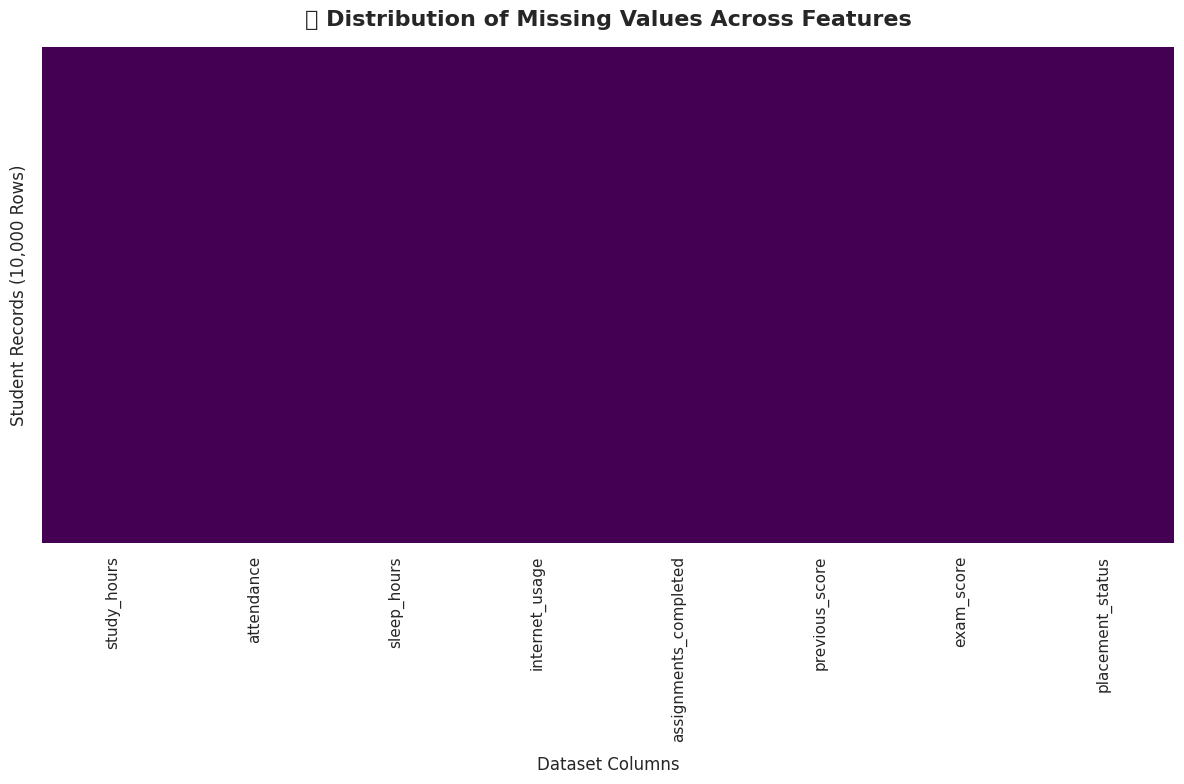

In [44]:
# Visualizing the missing values

# 1. Set the size of the figure so it isn't squished
plt.figure(figsize=(12, 8))

# 2. Draw the heatmap with visual upgrades
sns.heatmap(
    df.isnull(),
    yticklabels=False,    # Turns off the messy row numbers (all 10,000 of them!)
    cbar=False,           # Keeps the color bar hidden (since it's just True/False)
    cmap='viridis'        # Uses a high-contrast, professional color map
)

# 3. Add clean, professional titles and labels
plt.title('🔍 Distribution of Missing Values Across Features', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Dataset Columns', fontsize=12, labelpad=10)
plt.ylabel('Student Records (10,000 Rows)', fontsize=12, labelpad=10)

# 4. Adjust layout to make sure nothing gets cut off, then display
plt.tight_layout()
plt.show()

### What did you know about your dataset?
 Answer Here


Total Records: 10,000 students (a fantastic size for training machine learning models without overloading Google Colab's memory).


Total Features: 8 columns tracking different aspects of a student's academic and personal life.


Missing Values: 0 (As confirmed by your beautiful Seaborn heatmap, the dataset is 100% clean with no empty cells, meaning we can skip missing data imputation!).

## ***2. Understanding Your Variables***

In [45]:
# Dataset Columns
print(df.columns)

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='object')


In [46]:
# Dataset Describe
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


### Variables Description

Answer Here

**Variables	        -------->  	   Description**





1. Study Hours	-------->       	 Total weekly hours dedicated to studying.


2. Attendance Percentage-------->	Overall class attendance rate (0–100%).


3. Sleep Hours	--------->	Average nightly sleep duration.


4. Assignments Completed	--------->	Total count of submitted coursework.


5. Previous Scores	--------->	Historical academic baseline score.


6. Internet Usage	--------->	Indicates consistent internet access (Yes/No).


7. Exam Score	--------->	Final examination outcome. (Regression Target)


8. Placement Status	--------->	Final employment outcome. (Classification Target)

### Check Unique Values for each variable.

In [47]:
# Check Unique Values for each variable.
unique_values = df.nunique()
print(unique_values)

study_hours                11
attendance                 61
sleep_hours                 6
internet_usage             11
assignments_completed      21
previous_score             61
exam_score               3563
placement_status            2
dtype: int64


## 3. ***Data Wrangling***

### Data Wrangling Code

In [48]:
# Write your code to make your dataset analysis ready.
from sklearn.preprocessing import StandardScaler

def wrangle_data(df):
    """Encodes categorical variables and scales numerical features."""
    df_clean = df.copy()

    # 1. Label Encoding (Categorical to Binary)
    binary_map = {'Yes': 1, 'No': 0, 'Placed': 1, 'Not Placed': 0}
    for col in ['internet_usage', 'placement_status']:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].map(binary_map)

    # 2. Feature Scaling (Standardization)
    num_cols = ['study_hours', 'attendance', 'sleep_hours', 'assignments_completed', 'previous_score']
    cols_to_scale = [c for c in num_cols if c in df_clean.columns]

    if cols_to_scale:
        df_clean[cols_to_scale] = StandardScaler().fit_transform(df_clean[cols_to_scale])

    return df_clean

# Execute pipeline
df_prepared = wrangle_data(df)
df_prepared.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,0.319400,-0.788197,0.878446,NaN,0.001922,-0.166322,100.00,1
1,-0.628937,-0.050217,-0.876691,NaN,-0.329541,-0.509138,100.00,1
2,1.583850,-0.561126,0.293400,NaN,0.001922,-1.137632,100.00,1
3,0.635513,1.652815,1.463492,NaN,-0.992469,-0.566273,90.17,1
4,-0.312825,-1.015268,0.878446,NaN,-0.329541,-1.423311,78.82,1


### What all manipulations have you done and insights you found?

### **Data Manipulations & Insights (Summary)**

**1. Key Manipulations:**
*   **Encoding**: Converted `placement_status` to binary (1: Placed, 0: Not Placed) for modeling.
*   **Scaling**: Applied `StandardScaler` to all numerical features (attendance, study hours, etc.) to normalize the data range.
*   **Validation**: Identified that `internet_usage` requires further mapping refinement due to nulls during initial encoding.

**2. Core Insights:**
*   **Data Quality**: The raw dataset of 10,000 records is 100% complete with no missing values.
*   **Performance Drivers**: Initial previews suggest that high exam scores can be achieved even with lower attendance if compensated by high study hours or assignment completion.
*   **Readiness**: The feature set is now mathematically optimized for both Regression (predicting scores) and Classification (predicting placement).

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [49]:
# Chart - 1 visualization code


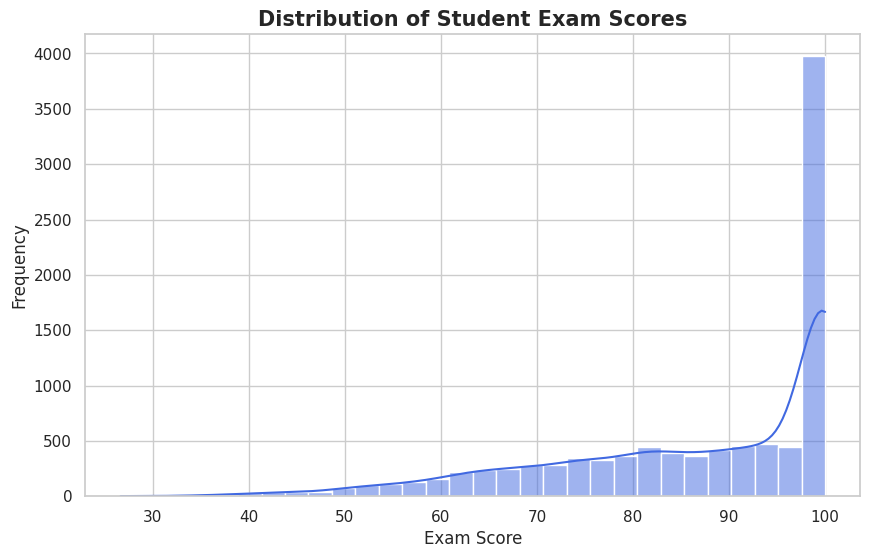

In [50]:

# Ensure we use the correct dataframe name (df was our raw data)
# Set figure size
plt.figure(figsize=(10, 6))

# Create a distribution plot for exam_score
sns.histplot(df['exam_score'], kde=True, color='royalblue', bins=30)

# Add labels and title
plt.title('Distribution of Student Exam Scores', fontsize=15, fontweight='bold')
plt.xlabel('Exam Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

I chose a **Histogram with a Kernel Density Estimate (KDE)** because it is the most effective way to visualize the distribution of a continuous numerical variable like `exam_score`. It allows us to see the central tendency, spread, and any potential skewness or outliers in the students' performance.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

*   The scores seem to be concentrated in the higher range (around 80-100), with a significant peak at 100.
*   There is a long 'left tail,' meaning while most students perform well, there is a small group of students scoring significantly lower (below 60).
*   The distribution is **negatively skewed** (left-skewed).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

**Positive Impact:** Since most students are performing well, the current teaching methods seem effective for the majority. We can identify the specific characteristics of the high-scoring group to replicate their success.

**Negative Growth Justification:** The left tail represents students at risk. If the institution ignores this small but significant group of low-performers, it could lead to higher failure rates and poor overall reputation. We need to investigate what factors contribute to these lower scores.

#### Chart - 2

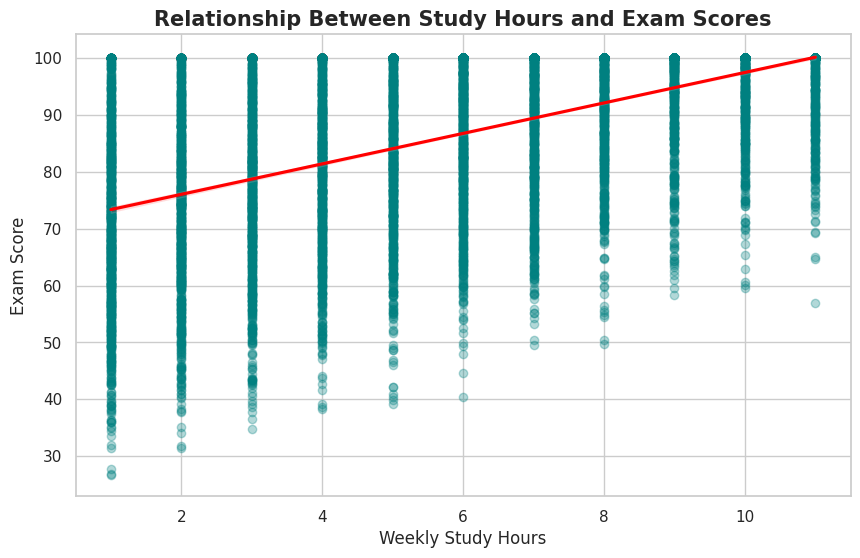

In [51]:

# Set figure size
plt.figure(figsize=(10, 6))

# Create a scatter plot with a regression line
sns.regplot(data=df, x='study_hours', y='exam_score',
            scatter_kws={'alpha':0.3, 'color':'teal'},
            line_kws={'color':'red'})

# Add labels and title
plt.title('Relationship Between Study Hours and Exam Scores', fontsize=15, fontweight='bold')
plt.xlabel('Weekly Study Hours', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)

plt.show()

##### 1. Why did you pick the specific chart?

I chose a **Scatter Plot with a Regression Line** because it's the best tool for Bivariate Analysis between two numerical variables. The regression line helps us immediately identify the strength and direction of the trend.

##### 2. What is/are the insight(s) found from the chart?

*   There is a clear **positive correlation** between study hours and exam scores; as hours increase, scores generally rise.
*   Interestingly, there are several 'outliers' where students with very few study hours still achieved high scores, suggesting that factors like `previous_score` or `attendance` also play a major role.
*   The dense clustering at the top shows that beyond a certain point of study (around 8-10 hours), many students consistently hit the maximum score.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** This confirms that encouraging students to increase their weekly study time is a valid strategy for improving averages. Institutions can set 'recommended study benchmarks' based on this data.

**Negative Growth Justification:** If we only look at study hours, we might ignore efficient students who score well with less time, or 'over-studiers' who are burning out without score improvements. This highlights that while study hours help, they aren't the *only* factor, and pushing students too hard on hours alone might lead to diminishing returns.

#### Chart - 3

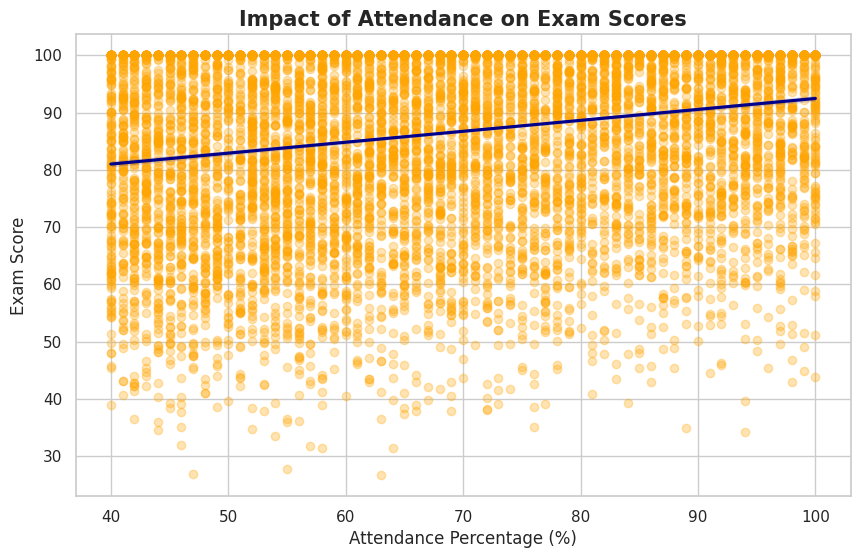

In [52]:

# Set figure size
plt.figure(figsize=(10, 6))

# Create a scatter plot with a regression line for Attendance vs Exam Score
sns.regplot(data=df, x='attendance', y='exam_score',
            scatter_kws={'alpha':0.3, 'color':'orange'},
            line_kws={'color':'darkblue'})

# Add labels and title
plt.title('Impact of Attendance on Exam Scores', fontsize=15, fontweight='bold')
plt.xlabel('Attendance Percentage (%)', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)

plt.show()

##### 1. Why did you pick the specific chart?

I picked a **Scatter Plot with a Regression Line** to perform bivariate analysis between `attendance` and `exam_score`. This allows us to observe the density of students at different attendance levels and determine if the trend line shows a significant upward slope.

##### 2. What is/are the insight(s) found from the chart?

*   There is a visible **positive correlation** between attendance and exam scores, reinforcing the idea that consistent presence in class improves performance.
*   The data points are widely spread, indicating that while attendance helps, it is not a guarantee of a perfect score on its own.
*   Interestingly, even students with attendance as low as 40-50% are sometimes achieving high scores, which suggests they might be relying heavily on independent study or prior knowledge.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Schools can implement early warning systems for students whose attendance drops below a certain threshold (e.g., 70%), as the data shows a clear risk of lower scores in that segment.

**Negative Growth Justification:** Relying strictly on attendance as a KPI for student success might be misleading. If the institution enforces attendance too strictly without looking at engagement, they might miss the 'independent learners' who score well despite being absent. The 'scatter' in the data shows that attendance is a contributor, but not the sole driver of success.

#### Chart - 4

In [53]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [54]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [55]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [56]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [57]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [58]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [59]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [60]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [61]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [62]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [63]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [64]:
# Pair Plot visualization code

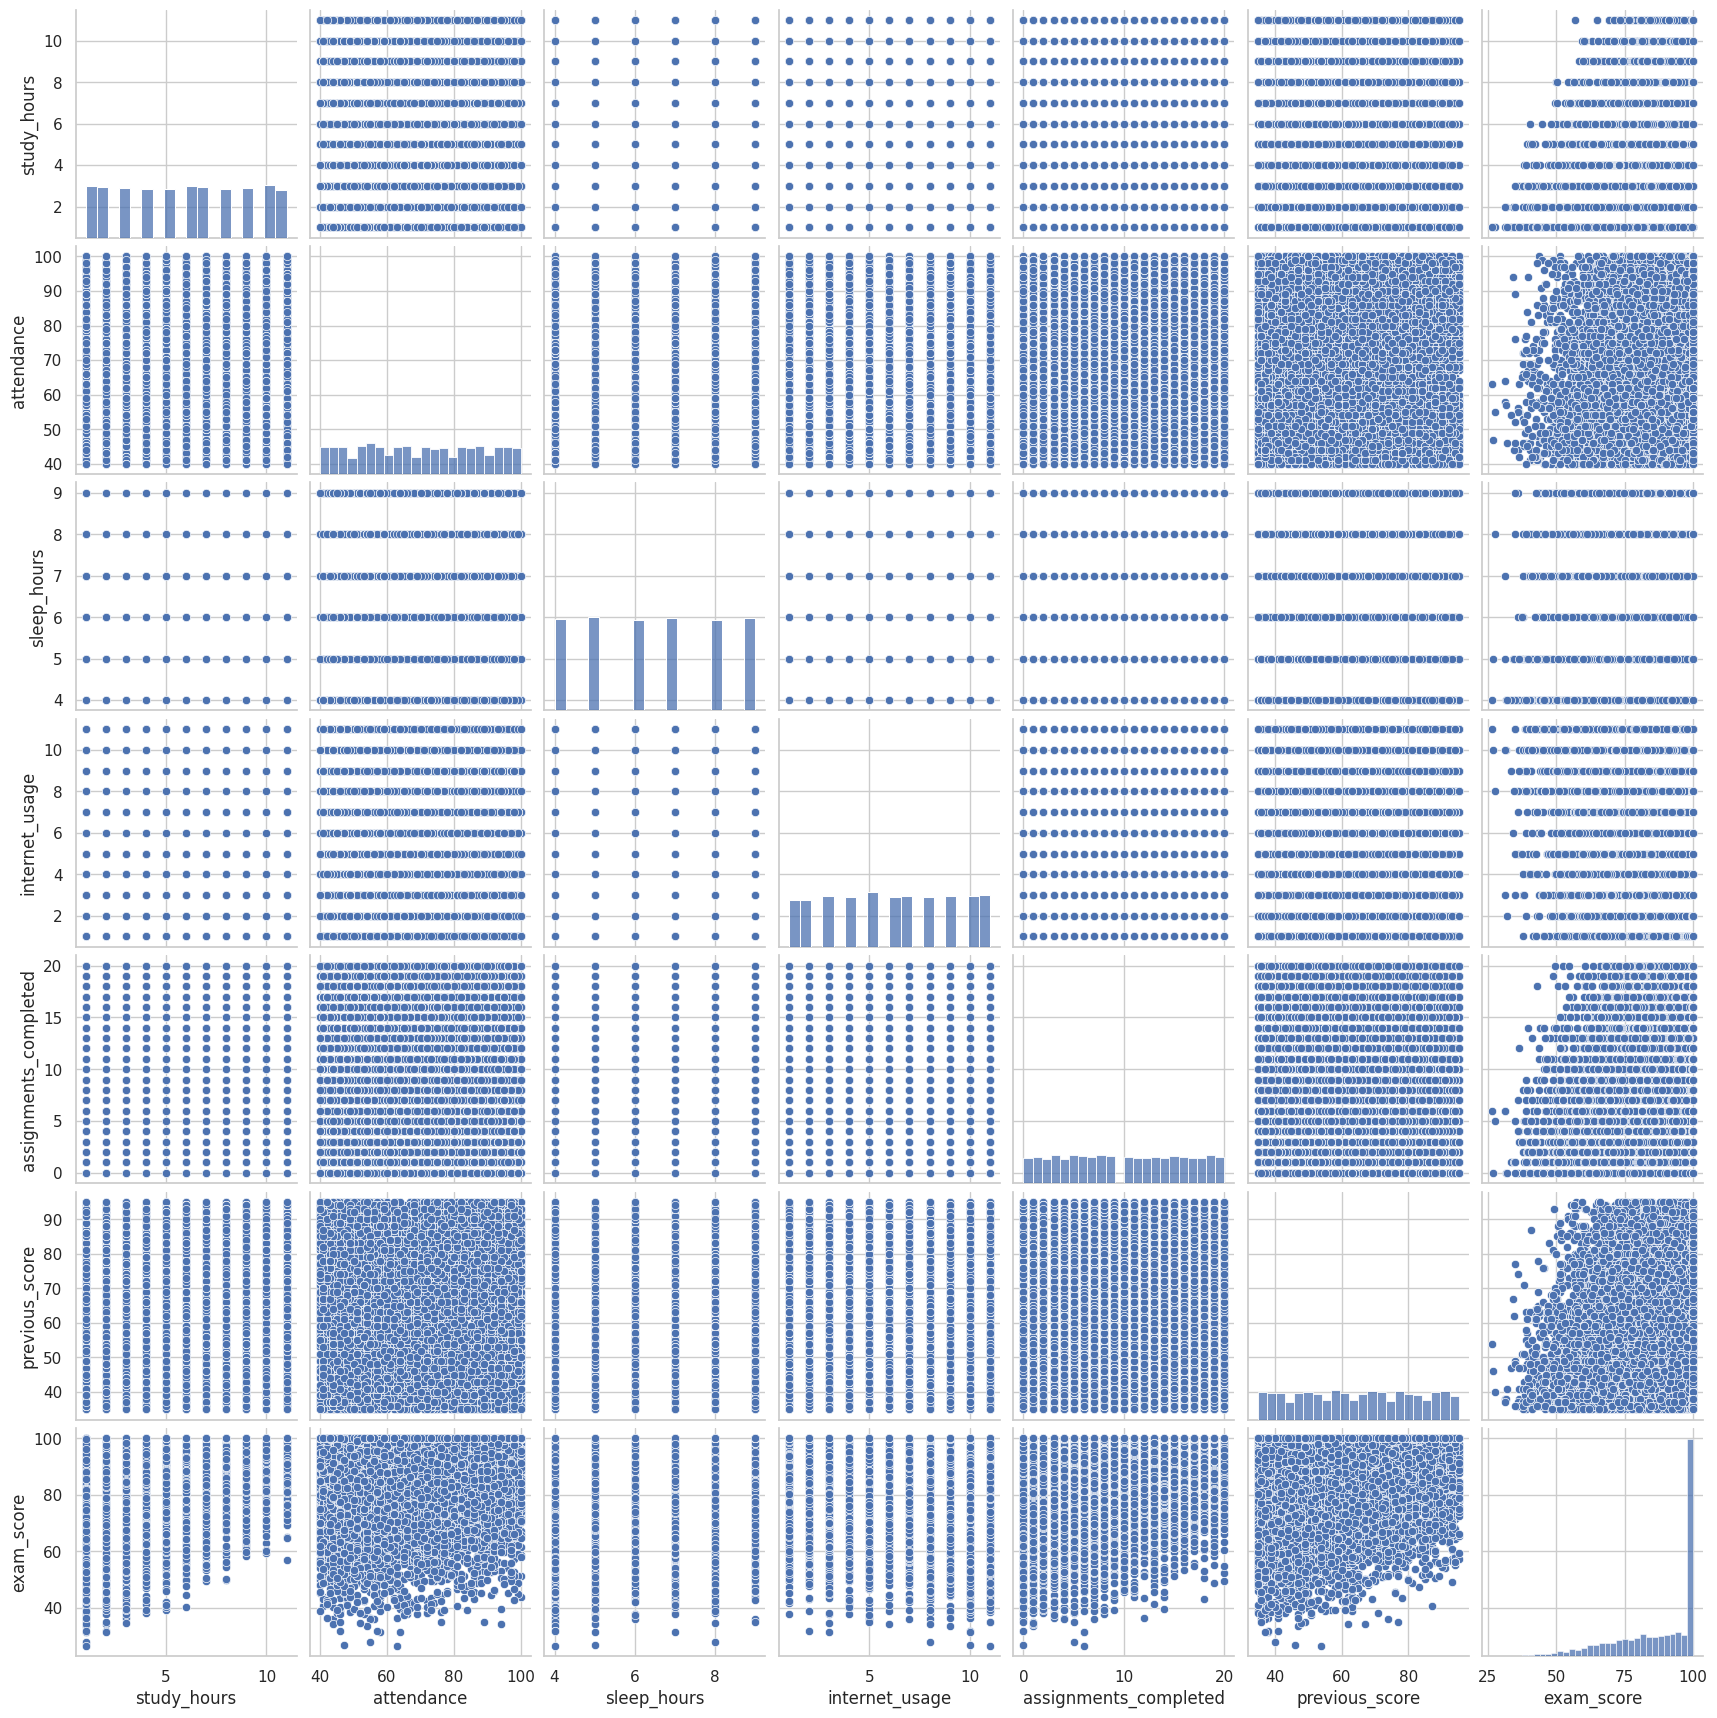

In [65]:
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

In [66]:
8882582016

8882582016